# k-NN — classificação dos estados do jogo da velha

Este experimento utiliza o algoritmo dos **k vizinhos mais próximos** para classificar
os quatro estados do jogo. Compara as duas representações de entrada com os mesmos
conjuntos de treino, validação e teste dos demais classificadores.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from threadpoolctl import threadpool_limits
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Configuração do experimento

Comparamos as mesmas amostras em duas representações: **A1**, com as nove casas numéricas
(`b=0`, `x=1`, `o=-1`), e **A2**, com 15 características derivadas. Nesta última, as posições
ocupadas são nove indicadores binários, um por casa. As demais características são contagens
de X e O, alinhamentos com duas marcas, casas vazias e próximo turno hipotético.
A semente 42 identifica a configuração reproduzível do experimento.

In [2]:
SEED = 42
RAIZ = next(
    (pasta for pasta in [Path.cwd(), *Path.cwd().parents]
     if (pasta / "dataset/processado/abordagem_1/treino.csv").is_file()),
    None,
)
if RAIZ is None:
    raise FileNotFoundError("Execute o notebook dentro da pasta deste projeto.")
BASE = RAIZ / "dataset/processado"

CLASSES = ["Tem jogo", "Jogador X venceu", "Jogador O venceu", "Empate"]
abordagens = {"abordagem_1": "A1 (tabuleiro)", "abordagem_2": "A2 (características)"}

figuras = {}

## 2. Leitura dos conjuntos preparados

Carregamos os CSVs de treino, validação e teste, separados fisicamente na preparação dos dados.
`X` contém as características e `y` contém o rótulo `estado`. Excluímos `id_tabuleiro`, que serve
para auditoria, e `estado`, que é a resposta a ser prevista, das entradas do classificador.
As divisões são compartilhadas por todos os algoritmos.

In [3]:
dados = {}
for ab in abordagens:
    d = {}
    for conjunto, sufixo in [("treino", "train"), ("validacao", "val"), ("teste", "test")]:
        df = pd.read_csv(f"{BASE}/{ab}/{conjunto}.csv")
        d[f"ids_{sufixo}"] = df["id_tabuleiro"]
        d[f"y_{sufixo}"] = df["estado"].values
        d[f"X_{sufixo}"] = df.drop(columns=["id_tabuleiro", "estado"])
    dados[ab] = d

for ab in abordagens:
    print(abordagens[ab])
    print("  X_train:", dados[ab]["X_train"].shape, " y_train:", dados[ab]["y_train"].shape)
    print("  X_val:  ", dados[ab]["X_val"].shape, " y_val:  ", dados[ab]["y_val"].shape)
    print("  X_test: ", dados[ab]["X_test"].shape, " y_test: ", dados[ab]["y_test"].shape)

A1 (tabuleiro)
  X_train: (560, 9)  y_train: (560,)
  X_val:   (92, 9)  y_val:   (92,)
  X_test:  (93, 9)  y_test:  (93,)
A2 (características)
  X_train: (560, 15)  y_train: (560,)
  X_val:   (92, 15)  y_val:   (92,)
  X_test:  (93, 15)  y_test:  (93,)


In [4]:
# classes em cada conjunto
d = dados["abordagem_1"]
pd.DataFrame({"treino": pd.Series(d["y_train"]).value_counts(),
              "validacao": pd.Series(d["y_val"]).value_counts(),
              "teste": pd.Series(d["y_test"]).value_counts()})

,treino,validacao,teste
Empate,140,2,3
Jogador O venceu,140,30,30
Jogador X venceu,140,30,30
Tem jogo,140,30,30


In [5]:
# Verificar a disjunção dos IDs para evitar o mesmo tabuleiro no treino e na avaliação.
ids_train, ids_val, ids_test = set(d["ids_train"]), set(d["ids_val"]), set(d["ids_test"])
print("treino x validação:", len(ids_train & ids_val))
print("treino x teste:    ", len(ids_train & ids_test))
print("validação x teste: ", len(ids_val & ids_test))
print("linhas do treino:", len(d["ids_train"]), "- tabuleiros distintos:", len(ids_train),
      "(repetições = empates reamostrados no treino)")

treino x validação: 0
treino x teste:     0
validação x teste:  0
linhas do treino: 560 - tabuleiros distintos: 431 (repetições = empates reamostrados no treino)


## 3. Definir as métricas de classificação

- **Acurácia:** proporção de previsões corretas entre todos os exemplos avaliados.
- **Precisão (precision):** entre as previsões de uma classe, proporção de exemplos que pertencem a ela.
- **Sensibilidade (recall):** entre os exemplos reais de uma classe, proporção reconhecida pelo modelo.
- **F1 (F-measure):** média harmônica entre precisão e recall, calculada por `2 × precisão × recall / (precisão + recall)`.

Para precisão, recall e F1, adotamos a média **macro**: calculamos a métrica separadamente
para cada uma das quatro classes e, depois, sua média aritmética. Cada classe recebe o
mesmo peso, inclusive **Empate**, que possui poucos exemplos. O F1 macro é a média dos
F1 por classe; ele não é calculado a partir das médias de precisão e recall.

Quando a divisão de uma métrica é indefinida, `zero_division=0` atribui zero.
A acurácia é calculada sobre o total de exemplos. A seleção dos parâmetros utiliza
F1 macro de validação, enquanto o teste é reservado à avaliação das configurações selecionadas.

Referência: [definição de F1 e média macro no scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

In [6]:
def metricas(y_real, y_pred):
    return {"acc": accuracy_score(y_real, y_pred),
            "precision": precision_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "recall": recall_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "f1_macro": f1_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0)}

## 4. Funcionamento do k-NN e parâmetros avaliados

O k-NN classifica um exemplo a partir dos `k` exemplos de treino mais próximos, segundo
uma medida de distância. A classe prevista resulta dos votos desses vizinhos.
É uma forma de **aprendizado baseado em exemplos**: o ajuste armazena os dados e pode
organizar a estrutura de busca; a classificação ocorre quando um novo exemplo é consultado.

- **Número de vizinhos (`n_neighbors`):** valores menores podem tornar a decisão mais sensível a exemplos individuais; valores maiores suavizam a fronteira e podem perder padrões locais.
- **Distância (`metric`):** comparamos a euclidiana, baseada na raiz da soma das diferenças quadráticas, e a de Manhattan, baseada na soma das diferenças absolutas.
- **Pesos dos votos (`weights`):** `uniform` atribui o mesmo peso aos vizinhos; `distance` dá maior peso aos mais próximos.

Na A2, aplicamos `StandardScaler` somente ao treino, dentro do `Pipeline`, para evitar
que características com maior escala dominem a distância. Na A1, mantemos a codificação
original, pois todas as casas possuem a mesma faixa numérica. O custo da busca depende
do número de exemplos, da dimensão e da estrutura utilizada; sua comparação é feita pelas medições.

Referência: [classificação por vizinhos no scikit-learn](https://scikit-learn.org/stable/modules/neighbors.html).

In [7]:
# Grade definida antes da avaliação no teste; a ordem determina o último desempate.
lista_k = [1, 3, 5, 7, 9, 11, 15]               # padrão 5
lista_metrica = ["euclidean", "manhattan"]      # padrão 'minkowski' (p=2 = euclidiana)
lista_pesos = ["uniform", "distance"]           # padrão 'uniform'

print("Combinações por abordagem:", len(lista_k) * len(lista_metrica) * len(lista_pesos))

Combinações por abordagem: 28


In [8]:
def criar_modelo(ab, k, metrica, pesos):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metrica, weights=pesos)
    if ab == "abordagem_2":
        return make_pipeline(StandardScaler(), knn)   # padroniza as características da A2
    return knn

## 5. Seleção dos parâmetros pela validação

Ajustamos cada combinação de parâmetros no conjunto de treino e avaliamos suas previsões
na validação. A seleção prioriza F1 macro de validação; em empate, considera a acurácia.
Se persistir empate, permanece a primeira configuração encontrada na ordem da grade.
Esse último critério é determinístico e não garante a configuração de menor complexidade.
O teste não participa da seleção.

Registramos também o F1 de treino. Uma diferença acentuada em relação à validação pode
indicar **sobreajuste (overfitting)**, isto é, adaptação excessiva aos exemplos de treino.
A diferença deve ser analisada junto com os resultados por classe e as limitações da amostra.

In [9]:
resultados = []   # uma linha para cada combinação testada
melhor = {}       # melhor modelo de cada abordagem (escolhido pela validação)

for ab in abordagens:
    d = dados[ab]
    for k in lista_k:
        for metrica in lista_metrica:
            for pesos in lista_pesos:
                modelo = criar_modelo(ab, k, metrica, pesos)
                modelo.fit(d["X_train"], d["y_train"])
                m_train = metricas(d["y_train"], modelo.predict(d["X_train"]))
                m_val = metricas(d["y_val"], modelo.predict(d["X_val"]))

                resultados.append({"abordagem": abordagens[ab], "k": k, "metrica": metrica, "pesos": pesos,
                                   "f1_treino": m_train["f1_macro"],
                                   "val_acc": m_val["acc"], "val_f1_macro": m_val["f1_macro"]})

                chave = (m_val["f1_macro"], m_val["acc"])
                if ab not in melhor or chave > melhor[ab]["chave"]:
                    melhor[ab] = {"chave": chave, "f1_treino": m_train["f1_macro"], "modelo": modelo,
                                  "params": {"k": k, "metrica": metrica, "pesos": pesos}}

resultados = pd.DataFrame(resultados)
print("Combinações testadas:", len(resultados))

Combinações testadas: 56


In [10]:
# melhor configuração de cada abordagem
for ab in abordagens:
    print(abordagens[ab], "->", melhor[ab]["params"], " F1 validação =", round(melhor[ab]["chave"][0], 3))

A1 (tabuleiro) -> {'k': 7, 'metrica': 'manhattan', 'pesos': 'uniform'}  F1 validação = 0.652
A2 (características) -> {'k': 3, 'metrica': 'manhattan', 'pesos': 'uniform'}  F1 validação = 0.886


In [11]:
# as 5 melhores combinações de cada abordagem (validação)
for ab in abordagens:
    print(abordagens[ab])
    top = resultados[resultados.abordagem == abordagens[ab]].sort_values(["val_f1_macro", "val_acc"], ascending=False)
    display(top.head(5).round(3))

A1 (tabuleiro)


,abordagem,k,metrica,pesos,f1_treino,val_acc,val_f1_macro
14,A1 (tabuleiro),7,manhattan,uniform,0.829,0.717,0.652
15,A1 (tabuleiro),7,manhattan,distance,1.000,0.739,0.632
19,A1 (tabuleiro),9,manhattan,distance,1.000,0.696,0.616
23,A1 (tabuleiro),11,manhattan,distance,1.000,0.685,0.605
10,A1 (tabuleiro),5,manhattan,uniform,0.852,0.707,0.597


A2 (características)


,abordagem,k,metrica,pesos,f1_treino,val_acc,val_f1_macro
34,A2 (características),3,manhattan,uniform,0.948,0.859,0.886
38,A2 (características),5,manhattan,uniform,0.951,0.859,0.886
39,A2 (características),5,manhattan,distance,0.991,0.837,0.869
32,A2 (características),3,euclidean,uniform,0.931,0.837,0.868
35,A2 (características),3,manhattan,distance,0.991,0.826,0.856


## 6. Avaliação no teste e medição do custo

As configurações foram selecionadas pela validação. O teste mede seu desempenho e
não modifica parâmetros ou a grade. As 20 repetições de ajuste e previsão medem
tempo médio e desvio padrão, com o paralelismo limitado a uma thread.

O tempo de previsão corresponde ao lote completo de 93 tabuleiros. Os tempos
incluem o padronizador quando presente; leitura dos CSVs e extração das características
não são cronometradas nesta etapa. A média por tabuleiro é amortizada pelo lote e
não representa a latência de uma chamada individual do front.

O [notebook de comparação](../comparacao/comparacao_classificadores.ipynb) mede
novamente as dez configurações sob o mesmo protocolo e inclui, separadamente,
o custo de obter as representações a partir dos tabuleiros.

In [12]:
REPETICOES_TEMPO = 20
tabela = []
previsoes = {}
for ab in abordagens:
    d = dados[ab]
    modelo = melhor[ab]["modelo"]
    params = melhor[ab]["params"]
    duracoes_treino, duracoes_pred = [], []
    # As repetições medem configurações fixadas; não realizam nova seleção.
    with threadpool_limits(limits=1):
        for _ in range(REPETICOES_TEMPO):
            novo_modelo = criar_modelo(ab, **params)
            inicio = time.perf_counter()
            novo_modelo.fit(d["X_train"], d["y_train"])
            duracoes_treino.append((time.perf_counter() - inicio) * 1000)
        for _ in range(REPETICOES_TEMPO):
            inicio = time.perf_counter()
            modelo.predict(d["X_test"])
            duracoes_pred.append((time.perf_counter() - inicio) * 1000)
        previsoes[ab] = modelo.predict(d["X_test"])
    m = metricas(d["y_test"], previsoes[ab])
    tabela.append({
        "codigo_abordagem": ab, "abordagem": abordagens[ab],
        "acuracia": m["acc"], "precision": m["precision"],
        "recall": m["recall"], "f1_macro": m["f1_macro"],
        "f1_treino": melhor[ab]["f1_treino"],
        "val_f1_macro": melhor[ab]["chave"][0], "val_acc": melhor[ab]["chave"][1],
        "gap_treino_val": melhor[ab]["f1_treino"] - melhor[ab]["chave"][0],
        "tempo_treino_ms": float(np.mean(duracoes_treino)),
        "tempo_treino_desvio_ms": float(np.std(duracoes_treino)),
        "tempo_pred_ms": float(np.mean(duracoes_pred)),
        "tempo_pred_desvio_ms": float(np.std(duracoes_pred)),
        "tempo_pred_por_tabuleiro_ms": float(np.mean(duracoes_pred)) / len(d["X_test"]),
    })
tabela = pd.DataFrame(tabela)
tabela.round(4)

,codigo_abordagem,abordagem,acuracia,precision,recall,f1_macro,f1_treino,val_f1_macro,val_acc,gap_treino_val,tempo_treino_ms,tempo_treino_desvio_ms,tempo_pred_ms,tempo_pred_desvio_ms,tempo_pred_por_tabuleiro_ms
0,abordagem_1,A1 (tabuleiro),0.6559,0.5625,0.5083,0.5174,0.8287,0.6516,0.7174,0.1771,0.7233,0.0641,1.0009,0.0550,0.0108
1,abordagem_2,A2 (características),0.8817,0.9080,0.9083,0.9073,0.9475,0.8861,0.8587,0.0614,1.3009,0.0522,1.1283,0.0784,0.0121


## 7. Resultados por classe e matriz de confusão

O relatório apresenta precisão, recall, F1 e suporte, isto é, quantidade de exemplos reais
por classe. As linhas da matriz de confusão representam classes reais e as colunas,
classes previstas. A diagonal reúne os acertos.

Há somente três empates no teste. Por isso, um único erro altera significativamente o recall
dessa classe, e uma pontuação alta deve ser interpretada com essa limitação.

In [13]:
for ab in abordagens:
    print(abordagens[ab])
    print(classification_report(dados[ab]["y_test"], previsoes[ab], labels=CLASSES, zero_division=0))

A1 (tabuleiro)
                  precision    recall  f1-score   support

        Tem jogo       0.83      0.50      0.62        30
Jogador X venceu       0.75      0.60      0.67        30
Jogador O venceu       0.67      0.93      0.78        30
          Empate       0.00      0.00      0.00         3

        accuracy                           0.66        93
       macro avg       0.56      0.51      0.52        93
    weighted avg       0.73      0.66      0.67        93

A2 (características)
                  precision    recall  f1-score   support

        Tem jogo       0.85      0.77      0.81        30
Jogador X venceu       0.81      0.87      0.84        30
Jogador O venceu       0.97      1.00      0.98        30
          Empate       1.00      1.00      1.00         3

        accuracy                           0.88        93
       macro avg       0.91      0.91      0.91        93
    weighted avg       0.88      0.88      0.88        93



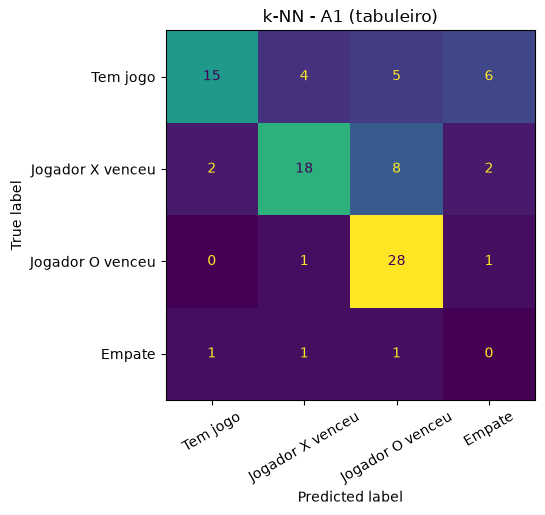

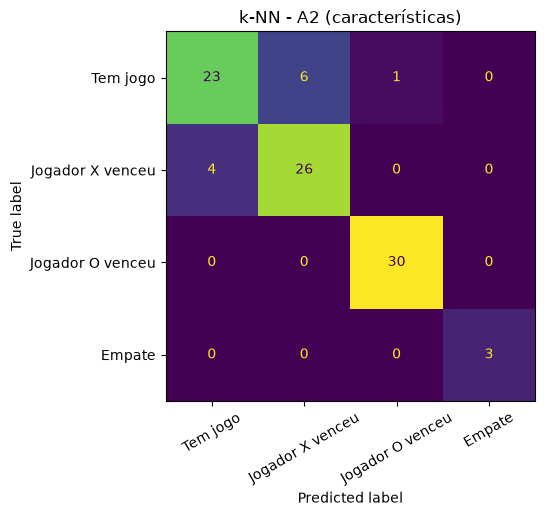

In [14]:
for ab in abordagens:
    resultado = confusion_matrix(dados[ab]["y_test"], previsoes[ab], labels=CLASSES)
    ConfusionMatrixDisplay(resultado, display_labels=CLASSES).plot(xticks_rotation=30, colorbar=False)
    plt.title(f"k-NN - {abordagens[ab]}")
    figuras[f"matriz_confusao_{ab}"] = plt.gcf()
    plt.show()

## 8. Treino e validação em função de número de vizinhos

Para cada valor do parâmetro, selecionamos a configuração pelo F1 macro de
validação e pela acurácia, mantendo a ordem da grade no último desempate.
Mostramos treino e validação **da mesma configuração**, preservando a associação
entre as métricas. Uma diferença acentuada pode indicar sobreajuste e deve
ser analisada com os resultados por classe.

O gráfico descreve a busca de parâmetros; não é uma curva por épocas e não
garante que aumentar o parâmetro sempre melhore ou estabilize o resultado.

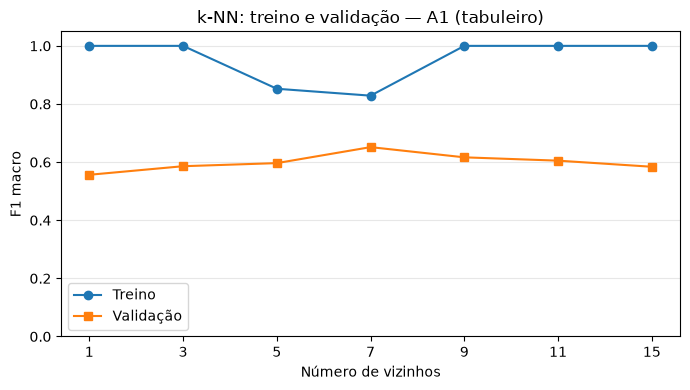

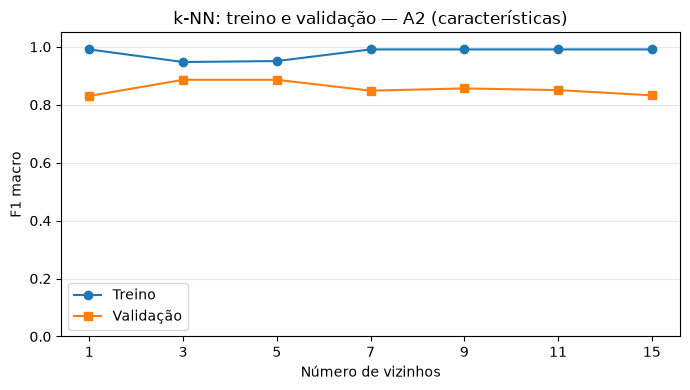

In [15]:
for ab in abordagens:
    s = resultados.loc[resultados["abordagem"] == abordagens[ab]].copy()
    # Ordenação estável preserva o desempate da grade, inclusive para None.
    s = s.sort_values(["val_f1_macro", "val_acc"], ascending=False, kind="stable")
    s = s.drop_duplicates("k").sort_values("k", na_position="last")
    rotulos = [str(int(v)) for v in s["k"]]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(len(s)), s["f1_treino"], marker="o", label="Treino")
    ax.plot(range(len(s)), s["val_f1_macro"], marker="s", label="Validação")
    ax.set_xticks(range(len(s)), rotulos)
    ax.set_xlabel("Número de vizinhos")
    ax.set_ylabel("F1 macro")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"k-NN: treino e validação — {abordagens[ab]}")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    figuras[f"treino_validacao_{ab}"] = fig
    plt.show()

In [16]:
# vizinhos mais próximos de um tabuleiro de teste (A1), para entender a decisão do k-NN
d = dados["abordagem_1"]
knn_a1 = melhor["abordagem_1"]["modelo"]
i = 0
dist, idx = knn_a1.kneighbors(d["X_test"].iloc[[i]])
print("Tabuleiro de teste:", d["ids_test"].iloc[i], "- classe real:", d["y_test"][i], "- previsto:", previsoes["abordagem_1"][i])
print("Vizinhos no treino:")
for dis, j in zip(dist[0], idx[0]):
    print("  ", d["ids_train"].iloc[j], d["y_train"][j], "distância =", round(dis, 2))

Tabuleiro de teste: xooxxbxbo - classe real: Jogador X venceu - previsto: Jogador X venceu
Vizinhos no treino:
   xboxbbxbo Jogador X venceu distância = 2.0
   xboxxbxoo Jogador X venceu distância = 2.0
   xbooxbxbo Tem jogo distância = 3.0
   bboxxoxbo Jogador O venceu distância = 3.0
   xooxbbbxo Tem jogo distância = 3.0
   xboxxobbo Jogador O venceu distância = 3.0
   xooxbxxob Jogador X venceu distância = 4.0


## 9. Comparação das abordagens A1 e A2

Comparamos qualidade e custo das configurações selecionadas. A diferença entre
treino e validação utiliza a mesma configuração em ambos os conjuntos. Mais
características não garantem maior custo nem melhor generalização: o resultado
também depende dos parâmetros e do algoritmo.

A análise escrita está na seção seguinte. A comparação dos cinco algoritmos
está no [notebook de comparação](../comparacao/comparacao_classificadores.ipynb).

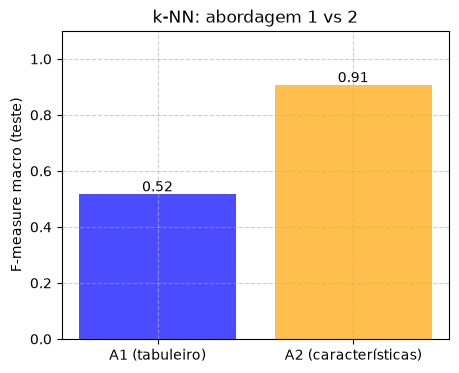

In [17]:
plt.figure(figsize=(5, 4))
plt.bar(tabela["abordagem"], tabela["f1_macro"], color=["blue", "orange"], alpha=0.7)
for i, v in enumerate(tabela["f1_macro"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.ylim(0, 1.1)
plt.ylabel("F-measure macro (teste)")
plt.title("k-NN: abordagem 1 vs 2")
plt.grid(True, linestyle="--", alpha=0.6)
figuras["f1_teste"] = plt.gcf()
plt.show()

In [18]:
tabela[["abordagem", "acuracia", "f1_macro", "gap_treino_val", "tempo_treino_ms", "tempo_pred_ms"]].round(3)

,abordagem,acuracia,f1_macro,gap_treino_val,tempo_treino_ms,tempo_pred_ms
0,A1 (tabuleiro),0.656,0.517,0.177,0.723,1.001
1,A2 (características),0.882,0.907,0.061,1.301,1.128


## 10. Análise dos resultados e conclusão

O texto utiliza os resultados desta execução: configuração, F1 de treino/validação/teste,
acurácia, custo e recomendação pela validação. Uma diferença grande entre treino e
validação pode indicar sobreajuste; uma diferença pequena não demonstra sua ausência.

A conclusão considera os poucos empates e a perda de informação de A2. A escolha
entre os cinco algoritmos está no [notebook de comparação](../comparacao/comparacao_classificadores.ipynb).

In [19]:
COMPLEMENTO_CONCLUSAO = '\n\n**Interpretação:** A2 selecionou três vizinhos e a distância de Manhattan. O F1 de treino superior ao de validação sugere atenção à generalização. As repetições de empates participam dos votos, e características iguais podem tornar a decisão sensível a empates entre vizinhos. A padronização de A2 pertence ao Pipeline e foi ajustada apenas no treino.'

ab_escolhida = max(abordagens, key=lambda ab: melhor[ab]["chave"])
conclusoes = []
for ab in abordagens:
    t = tabela.loc[tabela["codigo_abordagem"] == ab].iloc[0]
    empates = classification_report(dados[ab]["y_test"], previsoes[ab], labels=CLASSES,
                                    output_dict=True, zero_division=0)["Empate"]
    conclusoes.append(
        f"**{abordagens[ab]}:** configuração {melhor[ab]['params']}. "
        f"F1 macro: treino {t['f1_treino']:.3f}, validação {t['val_f1_macro']:.3f}, "
        f"teste {t['f1_macro']:.3f}; acurácia no teste {t['acuracia']:.2%}. "
        f"Diferença treino–validação: {t['gap_treino_val']:.3f}. "
        f"Treino médio {t['tempo_treino_ms']:.2f} ms; previsão do lote {t['tempo_pred_ms']:.3f} ms. "
        f"Reconheceu {int(round(empates['recall'] * empates['support']))} dos "
        f"{int(empates['support'])} empates do teste."
    )
t1, t2 = [tabela.loc[tabela["codigo_abordagem"] == ab].iloc[0] for ab in abordagens]
texto_conclusao = "\n\n".join(conclusoes)
texto_conclusao += (
    f"\n\n**Recomendação:** {abordagens[ab_escolhida]}, pelo F1 macro de validação "
    f"({melhor[ab_escolhida]['chave'][0]:.3f}) e pelos critérios de desempate declarados. "
    f"No teste, A2 superou A1 em {100 * (t2['f1_macro'] - t1['f1_macro']):.2f} "
    "pontos percentuais de F1 macro. Esse resultado descreve as configurações "
    "selecionadas; não prova que A2 seja melhor em qualquer amostra."
)
texto_conclusao += COMPLEMENTO_CONCLUSAO
texto_conclusao += (
    "\n\n**Custo e limitações:** as configurações de A1 e A2 podem ter complexidades "
    "diferentes. Interpretamos os tempos junto com seus parâmetros e a dispersão "
    "das medições. Há somente dois empates na validação e três no teste; a reamostragem "
    "não cria diversidade. A2 possui cinco grupos de entradas iguais com rótulos "
    "diferentes no treino. Possíveis simetrias entre divisões também limitam a análise."
)
display(Markdown(texto_conclusao))

**A1 (tabuleiro):** configuração {'k': 7, 'metrica': 'manhattan', 'pesos': 'uniform'}. F1 macro: treino 0.829, validação 0.652, teste 0.517; acurácia no teste 65.59%. Diferença treino–validação: 0.177. Treino médio 0.72 ms; previsão do lote 1.001 ms. Reconheceu 0 dos 3 empates do teste.

**A2 (características):** configuração {'k': 3, 'metrica': 'manhattan', 'pesos': 'uniform'}. F1 macro: treino 0.948, validação 0.886, teste 0.907; acurácia no teste 88.17%. Diferença treino–validação: 0.061. Treino médio 1.30 ms; previsão do lote 1.128 ms. Reconheceu 3 dos 3 empates do teste.

**Recomendação:** A2 (características), pelo F1 macro de validação (0.886) e pelos critérios de desempate declarados. No teste, A2 superou A1 em 39.00 pontos percentuais de F1 macro. Esse resultado descreve as configurações selecionadas; não prova que A2 seja melhor em qualquer amostra.

**Interpretação:** A2 selecionou três vizinhos e a distância de Manhattan. O F1 de treino superior ao de validação sugere atenção à generalização. As repetições de empates participam dos votos, e características iguais podem tornar a decisão sensível a empates entre vizinhos. A padronização de A2 pertence ao Pipeline e foi ajustada apenas no treino.

**Custo e limitações:** as configurações de A1 e A2 podem ter complexidades diferentes. Interpretamos os tempos junto com seus parâmetros e a dispersão das medições. Há somente dois empates na validação e três no teste; a reamostragem não cria diversidade. A2 possui cinco grupos de entradas iguais com rótulos diferentes no treino. Possíveis simetrias entre divisões também limitam a análise.

## 11. Exportação dos resultados e do modelo

Salvamos tabelas de configurações, métricas, treino/validação e custos das duas
abordagens. Previsões individuais, relatórios por classe, gráficos e conclusão
permitem reproduzir a análise no relatório sem extrair valores de imagens.

Exportamos somente o modelo da abordagem recomendada pela validação, incluindo
o padronizador do treino quando presente. Não há novo ajuste com validação ou teste.
O resumo registra versões, parâmetros e hashes dos CSVs.

In [20]:
import hashlib
import json
import platform

import joblib
import sklearn

ab_escolhida = max(abordagens, key=lambda ab: melhor[ab]["chave"])
modelo_exportado = melhor[ab_escolhida]["modelo"]
PASTA_RESULTADOS = BASE / "knn" / "resultados"
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

# Registrar ambas as abordagens, preservando a seleção pela validação.
linhas_predicoes, linhas_selecao = [], []
relatorios = {}
for ab in abordagens:
    d = dados[ab]
    linhas_predicoes.append(pd.DataFrame({
        "abordagem": ab, "id_tabuleiro": d["ids_test"].to_numpy(),
        "estado_real": d["y_test"], "estado_previsto": previsoes[ab],
        "acertou": d["y_test"] == previsoes[ab],
    }))
    relatorios[ab] = classification_report(d["y_test"], previsoes[ab], labels=CLASSES,
                                          output_dict=True, zero_division=0)
    linhas_selecao.append({
        "codigo_abordagem": ab, "abordagem": abordagens[ab],
        "f1_treino": melhor[ab]["f1_treino"], "val_f1_macro": melhor[ab]["chave"][0],
        "val_acc": melhor[ab]["chave"][1],
        "gap_treino_val": melhor[ab]["f1_treino"] - melhor[ab]["chave"][0],
        "n_features": d["X_train"].shape[1], **melhor[ab]["params"],
    })
pd.concat(linhas_predicoes, ignore_index=True).to_csv(PASTA_RESULTADOS / "previsoes_teste.csv", index=False)
pd.DataFrame(linhas_selecao).to_csv(PASTA_RESULTADOS / "configuracoes_selecionadas.csv", index=False)
tabela.to_csv(PASTA_RESULTADOS / "metricas_teste.csv", index=False)
resultados.to_csv(PASTA_RESULTADOS / "busca_validacao.csv", index=False)
(PASTA_RESULTADOS / "relatorios_por_classe.json").write_text(json.dumps(relatorios, ensure_ascii=False, indent=2) + "\n")
(PASTA_RESULTADOS / "conclusao.md").write_text(texto_conclusao + "\n", encoding="utf-8")
for nome_figura, figura in figuras.items():
    figura.savefig(PASTA_RESULTADOS / f"{nome_figura}.png", dpi=150, bbox_inches="tight")
d_exportado = dados[ab_escolhida]
previsoes_exportadas = previsoes[ab_escolhida]

arquivos_entrada = [
    BASE / ab / f"{conjunto}.csv"
    for ab in abordagens
    for conjunto in ["treino", "validacao", "teste"]
]
resumo = {
    "algoritmo": "k-NN", "semente": SEED,
    "versoes": {"python": platform.python_version(), "scikit_learn": sklearn.__version__,
                "pandas": pd.__version__, "joblib": joblib.__version__},
    "classes": CLASSES, "threads_blas": 1, "repeticoes_tempo": REPETICOES_TEMPO,
    "criterio_selecao_configuracao": "F1 macro de validação; acurácia; primeira configuração da grade",
    "criterio_selecao_abordagem": "F1 macro de validação; acurácia; primeira abordagem",
    "configuracoes_testadas": len(resultados),
    "abordagem_escolhida_pela_validacao": ab_escolhida,
    "configuracoes_selecionadas": {ab: info["params"] for ab, info in melhor.items()},
    "metricas_validacao": {
        ab: {"f1_macro": info["chave"][0], "acuracia": info["chave"][1]}
        for ab, info in melhor.items()
    },
    "features_modelo_exportado": list(d_exportado["X_train"].columns),
    "ordem_classes_modelo": list(map(str, modelo_exportado.classes_)),
    "metricas_teste_modelo_exportado": metricas(d_exportado["y_test"], previsoes_exportadas),
    "csvs_entrada_sha256": {
        str(caminho.relative_to(RAIZ)): hashlib.sha256(caminho.read_bytes()).hexdigest()
        for caminho in arquivos_entrada
    },
}
(PASTA_RESULTADOS / "resumo_experimento.json").write_text(
    json.dumps(resumo, ensure_ascii=False, indent=2) + "\n", encoding="utf-8",
)
joblib.dump(modelo_exportado, PASTA_RESULTADOS / "modelo_knn.joblib", compress=3)

print("Abordagem exportada:", abordagens[ab_escolhida])
print("Configuração:", melhor[ab_escolhida]["params"])
print("F1 macro de validação:", round(melhor[ab_escolhida]["chave"][0], 6))
print("Arquivos salvos em:", PASTA_RESULTADOS.relative_to(RAIZ))

Abordagem exportada: A2 (características)
Configuração: {'k': 3, 'metrica': 'manhattan', 'pesos': 'uniform'}
F1 macro de validação: 0.88613
Arquivos salvos em: dataset/processado/knn/resultados
